##***Clustering(RFM Analysis)***

###***Feature Selection for clustering***

Your RFM-style business dimensions
M = Monetary
total_charges
F = Frequency / Engagement
total_usage
total_calls
avg_call_duration
Usage pattern / behavior
day_usage_share
eve_usage_share
night_usage_share
intl_usage_share
Friction / dissatisfaction
number_customer_service_calls
service_calls_per_month_proxy
Special telecom behavior
total_intl_minutes
intl_mins_per_call

This is already very business-relevant.

In [ ]:
# # Select your features wisely to avoid overfitting
# cluster_features = [
#     # Value
#     'total_charges',

#     # Usage intensity
#     'total_usage',
#     'total_calls',
#     'avg_call_duration',

#     # Usage pattern
#     'day_usage_share',
#     'eve_usage_share',
#     'night_usage_share',
#     'intl_usage_share',

#     # Friction / dissatisfaction
#     'number_customer_service_calls',
#     'service_calls_per_month_proxy',

#     # International behavior
#     'total_intl_minutes',
#     'intl_mins_per_call'
# ]

In [ ]:
cluster_features = [
    'total_charges',
    'total_usage',
    'total_calls',
    'avg_call_duration',
    'day_usage_share',
    'eve_usage_share',
    'night_usage_share',
    'intl_usage_share',
    'number_customer_service_calls',
    'service_calls_per_month_proxy',
    'total_intl_minutes',
    'intl_mins_per_call'
]
X_cluster = df[cluster_features].copy()

In [ ]:
X_cluster.head()

,total_charges,total_usage,total_calls,avg_call_duration,day_usage_share,eve_usage_share,night_usage_share,intl_usage_share,number_customer_service_calls,service_calls_per_month_proxy,total_intl_minutes,intl_mins_per_call
0,59.24,625.2,332,1.883133,0.258477,0.312700,0.406910,0.021913,1,0.009259,13.7,3.425000
1,62.29,539.4,333,1.619820,0.451242,0.224694,0.301446,0.022618,0,0.000000,12.2,2.033333
2,66.80,564.8,255,2.214902,0.530099,0.109596,0.348619,0.011686,2,0.023529,6.6,0.825000
3,52.09,512.0,359,1.426184,0.325586,0.289648,0.365039,0.019727,3,0.039474,10.1,2.525000
4,78.31,786.8,321,2.451090,0.277326,0.442933,0.270208,0.009532,3,0.024590,7.5,0.937500


######Feature Scaling for Clustering

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

In [ ]:
X_cluster_scaled.shape

(4250, 12)

##### What all feature selection methods have you used  and why?

Used RFM Analysis for Feature Selection for customer segmentation using clustering.

##### Which all features you found important and why?

Answer Here.

###***Customer Segmentation analysis using clustering***

####Elbow Method for selecting the n clusters

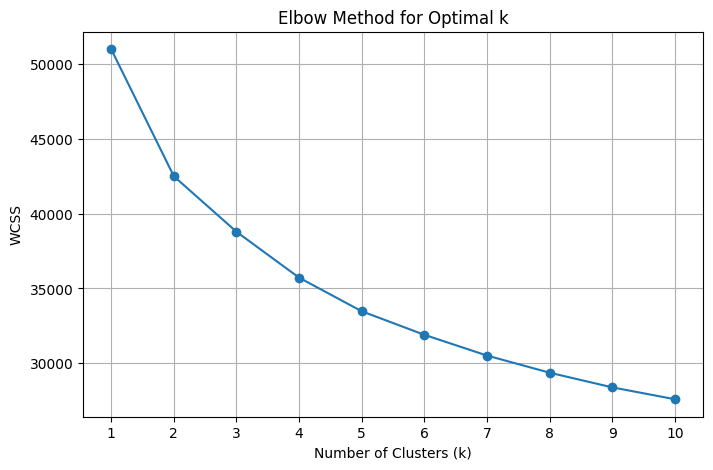

In [ ]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

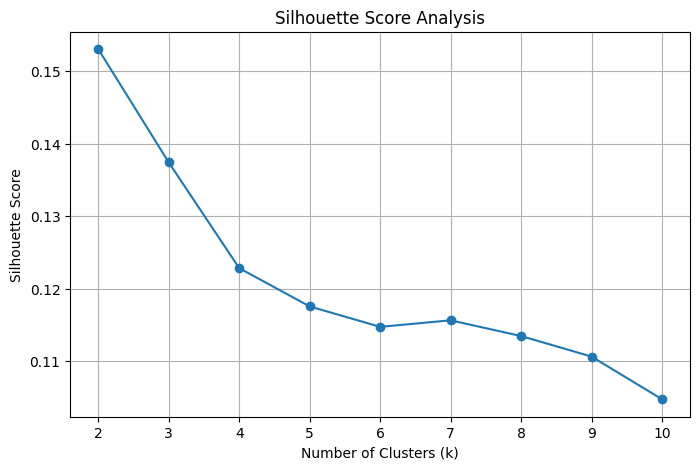

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cluster_scaled)
    score = silhouette_score(X_cluster_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Score Analysis')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

In [ ]:
for k, score in zip(range(2, 11), silhouette_scores):
    print(f'k = {k}, Silhouette Score = {score:.4f}')

k = 2, Silhouette Score = 0.1530
k = 3, Silhouette Score = 0.1374
k = 4, Silhouette Score = 0.1228
k = 5, Silhouette Score = 0.1175
k = 6, Silhouette Score = 0.1147
k = 7, Silhouette Score = 0.1156
k = 8, Silhouette Score = 0.1134
k = 9, Silhouette Score = 0.1106
k = 10, Silhouette Score = 0.1047


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cluster_eval = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cluster_scaled)

    cluster_eval.append({
        'k': k,
        'wcss': kmeans.inertia_,
        'silhouette_score': silhouette_score(X_cluster_scaled, labels)
    })

cluster_eval_df = pd.DataFrame(cluster_eval)
cluster_eval_df

,k,wcss,silhouette_score
0,2,42504.438090,0.153029
1,3,38794.170826,0.137400
2,4,35723.275984,0.122813
3,5,33476.914673,0.117535
4,6,31901.877939,0.114713
5,7,30515.536586,0.115619
6,8,29368.163415,0.113446
7,9,28388.395414,0.110613
8,10,27594.375443,0.104728


In [ ]:
cluster_df = df.copy()

In [ ]:
from sklearn.cluster import KMeans

kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_df['cluster_3'] = kmeans_3.fit_predict(X_cluster_scaled)

In [ ]:
cluster_df['cluster_3'].value_counts()

,count
cluster_3,
0,1735
2,1530
1,985


In [ ]:
cluster_summary_3 = cluster_df.groupby('cluster_3')[cluster_features].mean().round(2)
cluster_summary_3

,total_charges,total_usage,total_calls,avg_call_duration,day_usage_share,eve_usage_share,night_usage_share,intl_usage_share,number_customer_service_calls,service_calls_per_month_proxy,total_intl_minutes,intl_mins_per_call
cluster_3,,,,,,,,,,,,
0,66.76,652.33,296.98,2.22,0.33,0.33,0.33,0.02,0.98,0.01,9.77,2.15
1,60.67,596.80,307.60,1.96,0.32,0.34,0.33,0.02,3.18,0.04,9.96,2.21
2,50.39,518.32,310.62,1.68,0.27,0.35,0.36,0.02,1.18,0.01,10.98,2.43


In [ ]:
(cluster_df.groupby('cluster_3')['churn_flag'].mean() * 100).round(2)

,churn_flag
cluster_3,
0,16.66
1,20.81
2,6.80


In [ ]:
cluster_flags_3 = cluster_df.groupby('cluster_3')[[
    'high_value_customer_flag',
    'high_service_issue_flag',
    'high_value_dissatisfied_flag',
    'is_day_heavy_user',
    'is_intl_heavy_user',
    'churn_flag'
]].mean().round(3)

cluster_flags_3

,high_value_customer_flag,high_service_issue_flag,high_value_dissatisfied_flag,is_day_heavy_user,is_intl_heavy_user,churn_flag
cluster_3,,,,,,
0,0.476,0.002,0.038,0.035,0.071,0.167
1,0.234,0.322,0.174,0.027,0.171,0.208
2,0.004,0.010,0.000,0.021,0.505,0.068


In [ ]:
kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_df['cluster_4'] = kmeans_4.fit_predict(X_cluster_scaled)

In [ ]:
cluster_df['cluster_4'].value_counts()

,count
cluster_4,
0,1259
2,1201
1,998
3,792


In [ ]:
cluster_summary_4 = cluster_df.groupby('cluster_4')[cluster_features].mean().round(2)
cluster_summary_4

,total_charges,total_usage,total_calls,avg_call_duration,day_usage_share,eve_usage_share,night_usage_share,intl_usage_share,number_customer_service_calls,service_calls_per_month_proxy,total_intl_minutes,intl_mins_per_call
cluster_4,,,,,,,,,,,,
0,68.92,666.07,291.38,2.30,0.33,0.33,0.32,0.02,1.03,0.01,11.00,2.53
1,57.43,580.09,313.73,1.86,0.30,0.34,0.35,0.01,1.17,0.01,7.36,1.45
2,50.11,514.46,308.96,1.68,0.27,0.35,0.36,0.02,1.26,0.01,11.81,2.69
3,61.11,602.65,306.14,1.99,0.31,0.34,0.33,0.02,3.36,0.04,10.33,2.25


In [ ]:
(cluster_df.groupby('cluster_4')['churn_flag'].mean() * 100).round(2)

,churn_flag
cluster_4,
0,21.53
1,4.91
2,7.91
3,23.11


In [ ]:
cluster_flags_4 = cluster_df.groupby('cluster_4')[[
    'high_value_customer_flag',
    'high_service_issue_flag',
    'high_value_dissatisfied_flag',
    'is_day_heavy_user',
    'is_intl_heavy_user',
    'churn_flag'
]].mean().round(3)

cluster_flags_4

,high_value_customer_flag,high_service_issue_flag,high_value_dissatisfied_flag,is_day_heavy_user,is_intl_heavy_user,churn_flag
cluster_4,,,,,,
0,0.608,0.002,0.054,0.037,0.122,0.215
1,0.092,0.007,0.011,0.030,0.000,0.049
2,0.003,0.017,0.000,0.021,0.639,0.079
3,0.251,0.385,0.199,0.021,0.179,0.231


Customer Segmentation using KMeans Clustering

To enrich the churn analysis with customer behavior insights, KMeans clustering was applied on selected behavioral and value-based features such as usage, charges, call patterns, international behavior, and service interaction intensity.

Although silhouette scores indicated only moderate-to-weak natural separation (common in real-world customer behavior data), cluster solutions were further evaluated from a business interpretability perspective.

After comparing k = 3 and k = 4, the 4-cluster solution was selected because it provided more meaningful and actionable customer segments, including:

**High-Value Heavy Users at Risk**

**Low-Risk Routine Users**

**International-Focused Low-Value Users**

**Frustrated / Service-Stressed Customers**

These segments helped connect behavioral patterns with churn risk and enabled segment-specific retention recommendations.

In [ ]:
# Final selected clustering solution
df['customer_segment'] = cluster_df['cluster_4']

In [ ]:
# Business-friendly segment names
segment_map = {
    0: 'High-Value Heavy Users at Risk',
    1: 'Low-Risk Routine Users',
    2: 'International-Focused Low-Value Users',
    3: 'Frustrated / Service-Stressed Customers'
}

cluster_df['customer_segment_name'] = cluster_df['cluster_4'].map(segment_map)

# Quick check
cluster_df[['cluster_4', 'customer_segment_name']].head()

,cluster_4,customer_segment_name
0,2,International-Focused Low-Value Users
1,2,International-Focused Low-Value Users
2,1,Low-Risk Routine Users
3,3,Frustrated / Service-Stressed Customers
4,0,High-Value Heavy Users at Risk


In [ ]:
segment_counts = cluster_df['customer_segment_name'].value_counts().reset_index()
segment_counts.columns = ['customer_segment_name', 'count']
segment_counts

,customer_segment_name,count
0,High-Value Heavy Users at Risk,1259
1,International-Focused Low-Value Users,1201
2,Low-Risk Routine Users,998
3,Frustrated / Service-Stressed Customers,792


In [ ]:
segment_distribution = (
    cluster_df['customer_segment_name']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

segment_distribution.columns = ['customer_segment_name', 'percentage']
segment_distribution

,customer_segment_name,percentage
0,High-Value Heavy Users at Risk,29.62
1,International-Focused Low-Value Users,28.26
2,Low-Risk Routine Users,23.48
3,Frustrated / Service-Stressed Customers,18.64


In [ ]:
segment_summary = cluster_df.groupby('customer_segment_name')[[
    'total_charges',
    'total_usage',
    'total_calls',
    'avg_call_duration',
    'number_customer_service_calls',
    'service_calls_per_month_proxy',
    'total_intl_minutes',
    'intl_mins_per_call',
    'churn_flag'
]].mean().round(2)

segment_summary

,total_charges,total_usage,total_calls,avg_call_duration,number_customer_service_calls,service_calls_per_month_proxy,total_intl_minutes,intl_mins_per_call,churn_flag
customer_segment_name,,,,,,,,,
Frustrated / Service-Stressed Customers,61.11,602.65,306.14,1.99,3.36,0.04,10.33,2.25,0.23
High-Value Heavy Users at Risk,68.92,666.07,291.38,2.30,1.03,0.01,11.00,2.53,0.22
International-Focused Low-Value Users,50.11,514.46,308.96,1.68,1.26,0.01,11.81,2.69,0.08
Low-Risk Routine Users,57.43,580.09,313.73,1.86,1.17,0.01,7.36,1.45,0.05


In [ ]:
segment_summary['customer_count'] = cluster_df['customer_segment_name'].value_counts()
segment_summary = segment_summary[[
    'customer_count',
    'total_charges',
    'total_usage',
    'total_calls',
    'avg_call_duration',
    'number_customer_service_calls',
    'service_calls_per_month_proxy',
    'total_intl_minutes',
    'intl_mins_per_call',
    'churn_flag'
]]

segment_summary

,customer_count,total_charges,total_usage,total_calls,avg_call_duration,number_customer_service_calls,service_calls_per_month_proxy,total_intl_minutes,intl_mins_per_call,churn_flag
customer_segment_name,,,,,,,,,,
Frustrated / Service-Stressed Customers,792,61.11,602.65,306.14,1.99,3.36,0.04,10.33,2.25,0.23
High-Value Heavy Users at Risk,1259,68.92,666.07,291.38,2.30,1.03,0.01,11.00,2.53,0.22
International-Focused Low-Value Users,1201,50.11,514.46,308.96,1.68,1.26,0.01,11.81,2.69,0.08
Low-Risk Routine Users,998,57.43,580.09,313.73,1.86,1.17,0.01,7.36,1.45,0.05


In [ ]:
segment_flags_summary = cluster_df.groupby('customer_segment_name')[[
    'high_value_customer_flag',
    'high_service_issue_flag',
    'high_value_dissatisfied_flag',
    'is_day_heavy_user',
    'is_intl_heavy_user',
    'churn_flag'
]].mean().round(3)

segment_flags_summary

,high_value_customer_flag,high_service_issue_flag,high_value_dissatisfied_flag,is_day_heavy_user,is_intl_heavy_user,churn_flag
customer_segment_name,,,,,,
Frustrated / Service-Stressed Customers,0.251,0.385,0.199,0.021,0.179,0.231
High-Value Heavy Users at Risk,0.608,0.002,0.054,0.037,0.122,0.215
International-Focused Low-Value Users,0.003,0.017,0.000,0.021,0.639,0.079
Low-Risk Routine Users,0.092,0.007,0.011,0.030,0.000,0.049


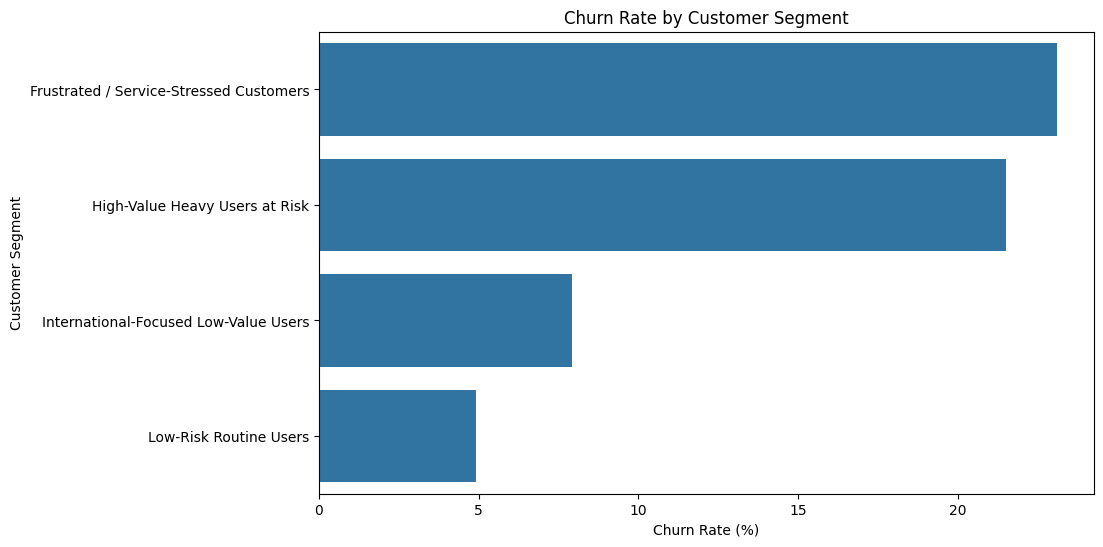

In [ ]:
churn_by_segment = (
    cluster_df.groupby('customer_segment_name')['churn_flag']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=churn_by_segment.values,
    y=churn_by_segment.index
)
plt.title('Churn Rate by Customer Segment')
plt.xlabel('Churn Rate (%)')
plt.ylabel('Customer Segment')
plt.show()

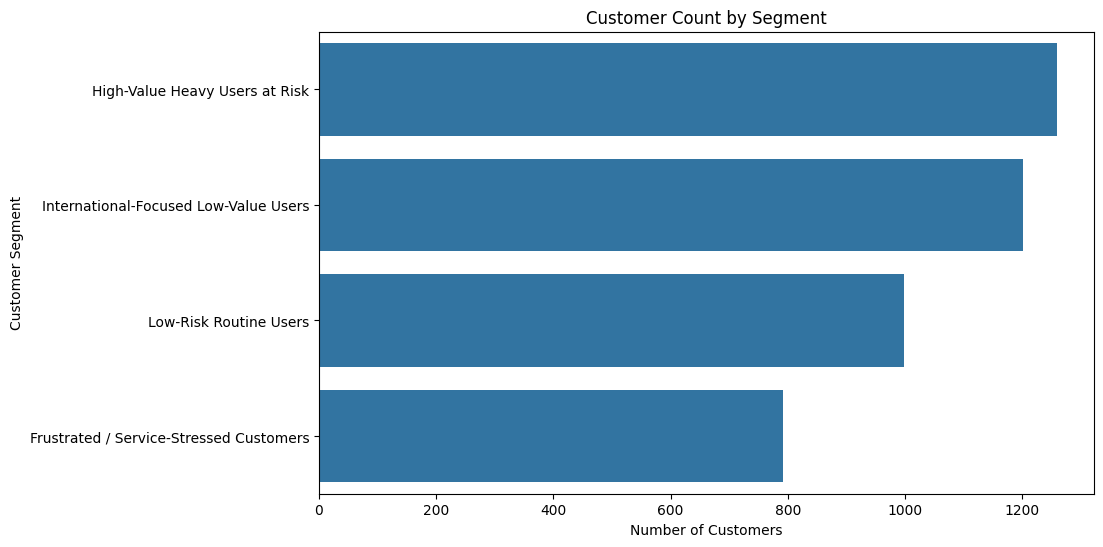

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=cluster_df,
    y='customer_segment_name',
    order= cluster_df['customer_segment_name'].value_counts().index
)
plt.title('Customer Count by Segment')
plt.xlabel('Number of Customers')
plt.ylabel('Customer Segment')
plt.show()

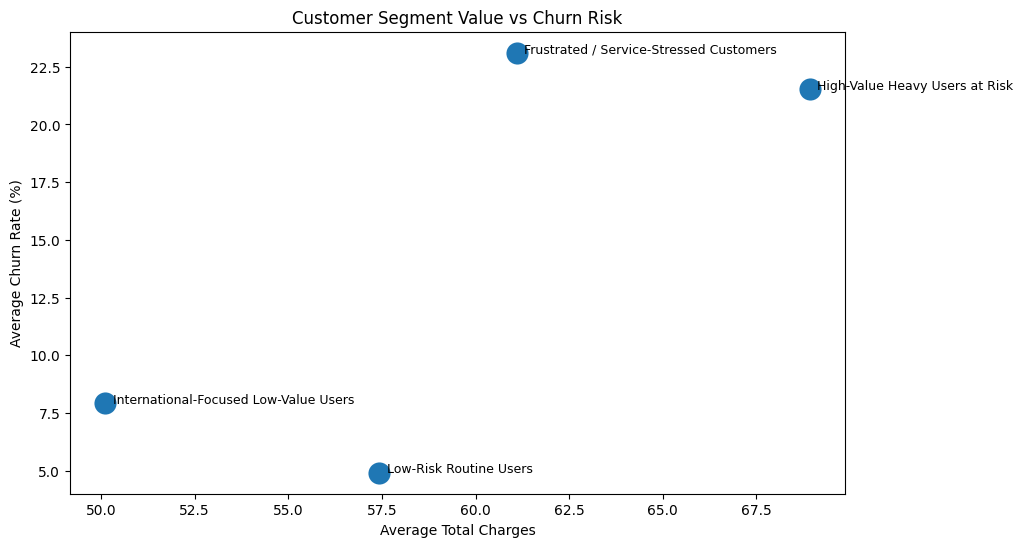

In [ ]:
value_risk_df = cluster_df.groupby('customer_segment_name').agg({
    'total_charges': 'mean',
    'churn_flag': 'mean'
}).reset_index()

value_risk_df['churn_flag'] = value_risk_df['churn_flag'] * 100

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=value_risk_df,
    x='total_charges',
    y='churn_flag',
    s=300
)

for i in range(len(value_risk_df)):
    plt.text(
        value_risk_df['total_charges'][i] + 0.2,
        value_risk_df['churn_flag'][i],
        value_risk_df['customer_segment_name'][i],
        fontsize=9
    )

plt.title('Customer Segment Value vs Churn Risk')
plt.xlabel('Average Total Charges')
plt.ylabel('Average Churn Rate (%)')
plt.show()

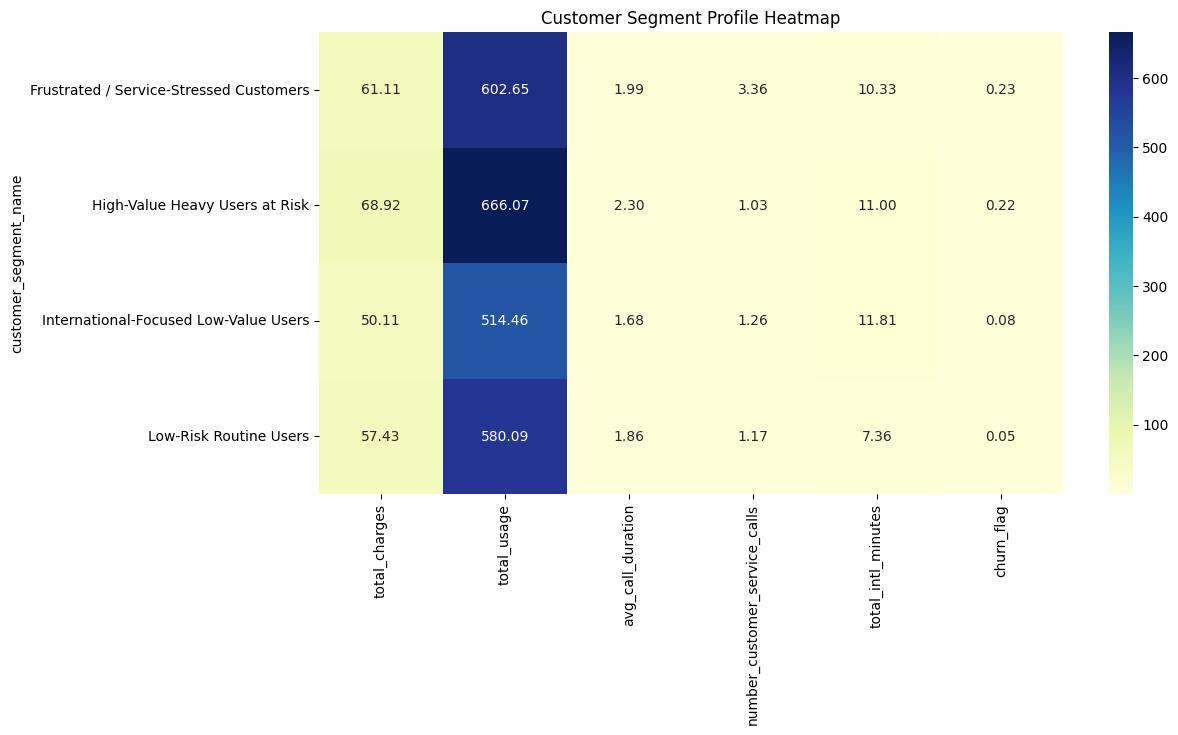

In [ ]:
segment_heatmap = cluster_df.groupby('customer_segment_name')[[
    'total_charges',
    'total_usage',
    'avg_call_duration',
    'number_customer_service_calls',
    'total_intl_minutes',
    'churn_flag'
]].mean()

plt.figure(figsize=(12, 6))
sns.heatmap(segment_heatmap, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Customer Segment Profile Heatmap')
plt.show()

In [ ]:
retention_strategy = pd.DataFrame({
    'Customer Segment': [
        'High-Value Heavy Users at Risk',
        'Low-Risk Routine Users',
        'International-Focused Low-Value Users',
        'Frustrated / Service-Stressed Customers'
    ],
    'Key Characteristics': [
        'High spend, high usage, long call duration, elevated churn',
        'Frequent short domestic calls, low churn, stable behavior',
        'Low value overall, high international calling behavior',
        'High complaint intensity, dissatisfaction, highest churn'
    ],
    'Business Risk': [
        'High revenue loss risk',
        'Low immediate churn risk',
        'Moderate niche segment risk',
        'High dissatisfaction-driven churn risk'
    ],
    'Suggested Retention Strategy': [
        'Offer loyalty rewards, premium retention plans, personalized engagement',
        'Maintain satisfaction, monitor for upsell opportunities',
        'Promote international packs, roaming bundles, targeted offers',
        'Prioritize complaint resolution, proactive support outreach, service recovery'
    ]
})

retention_strategy

,Customer Segment,Key Characteristics,Business Risk,Suggested Retention Strategy
0,High-Value Heavy Users at Risk,"High spend, high usage, long call duration, el...",High revenue loss risk,"Offer loyalty rewards, premium retention plans..."
1,Low-Risk Routine Users,"Frequent short domestic calls, low churn, stab...",Low immediate churn risk,"Maintain satisfaction, monitor for upsell oppo..."
2,International-Focused Low-Value Users,"Low value overall, high international calling ...",Moderate niche segment risk,"Promote international packs, roaming bundles, ..."
3,Frustrated / Service-Stressed Customers,"High complaint intensity, dissatisfaction, hig...",High dissatisfaction-driven churn risk,"Prioritize complaint resolution, proactive sup..."


**Customer Segmentation for Churn Intelligence**

To go beyond pure churn prediction, customers were segmented using KMeans clustering on selected behavioral, value, and service interaction features.

The objective was to identify distinct customer behavior groups and understand how churn risk differs across these segments.

Although clustering metrics showed weak-to-moderate natural separation (common in real-world customer behavior data), the clustering solution was evaluated not only on technical metrics but also on business interpretability and actionability.

After comparing multiple cluster solutions, the 4-cluster segmentation was selected because it provided the most meaningful and business-relevant customer groups:

**High-Value Heavy Users at Risk**

**Low-Risk Routine Users**

**International-Focused Low-Value Users**

**Frustrated / Service-Stressed Customers**

**Key business insights:**

**Frustrated / Service-Stressed Customers** showed the highest churn rate, indicating strong dissatisfaction-driven churn.

**High-Value Heavy Users at Risk** represented an especially critical segment, as they combined high revenue value with elevated churn risk.

**Low-Risk Routine Users** formed the most stable customer group.

**International-Focused Low-Value Users** emerged as a niche segment with distinct usage behavior and relatively lower churn.

This segmentation added a valuable customer intelligence layer to the churn project, enabling segment-specific retention strategies instead of one-size-fits-all churn interventions.

**Best Insights**

1.

The clustering analysis revealed that churn was not evenly distributed across the customer base; instead, it was concentrated in specific behavioral segments.

2.

The highest-risk segment was driven not just by usage patterns but by elevated customer service interactions, highlighting dissatisfaction as a major churn driver.

3.

One of the most business-critical findings was the existence of a high-value customer segment with elevated churn risk, representing a direct revenue retention opportunity.

4.

This segmentation transformed the project from a pure prediction task into a more strategic customer retention intelligence use case.